In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import All 7 Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- CONFIGURATION ---
UCI_COLUMNS = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
               'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
FILE_CLV = 'data/processed.cleveland.data.csv'
FILE_HUN = 'data/processed.hungarian.data.csv'
FILE_KGL = 'data/heart_statlog_cleveland_hungary_final.csv'

sns.set_style("whitegrid")

In [42]:
# ==========================================
# 1. PREPARING THE DATASETS
# ==========================================
datasets = {}

# --- D1: Hungarian (Dropped Rows) ---
df1 = pd.read_csv(FILE_HUN, names=UCI_COLUMNS, na_values='?')
df1 = df1.drop(['ca', 'thal'], axis=1).dropna()
df1['target'] = df1['target'].apply(lambda x: 1 if x > 0 else 0)
datasets['1. Hungarian (Dropped)'] = (df1.drop('target', axis=1), df1['target'])

# --- D2: Hungarian (Imputed + Dropped Cols) ---
df2_raw = pd.read_csv(FILE_HUN, names=UCI_COLUMNS, na_values='?')
df2_raw = df2_raw.drop(['ca', 'thal'], axis=1)
imputer = SimpleImputer(strategy='mean') #Impute = Yerine atama.
df2_imp = pd.DataFrame(imputer.fit_transform(df2_raw), columns=df2_raw.columns)
df2_imp['target'] = df2_imp['target'].apply(lambda x: 1 if x > 0 else 0)
datasets['2. Hungarian (Imputed + Dropped)'] = (df2_imp.drop('target', axis=1), df2_imp['target'])

# --- D3: Hungarian (Imputed + NOT Dropped Cols) ---
df3_raw = pd.read_csv(FILE_HUN, names=UCI_COLUMNS, na_values='?')
imputer = SimpleImputer(strategy='mean')
df3_imp = pd.DataFrame(imputer.fit_transform(df3_raw), columns=df3_raw.columns)
df3_imp['target'] = df3_imp['target'].apply(lambda x: 1 if x > 0 else 0)
datasets['3. Hungarian (Imputed + NOT Dropped)'] = (df3_imp.drop('target', axis=1), df3_imp['target'])

# --- D4: Cleveland (Reduced) ---
df4 = pd.read_csv(FILE_CLV, names=UCI_COLUMNS, na_values='?')
df4 = df4.drop(['ca', 'thal'], axis=1).dropna()
df4['target'] = df4['target'].apply(lambda x: 1 if x > 0 else 0)
datasets['4. Cleveland (Reduced)'] = (df4.drop('target', axis=1), df4['target'])

# --- D5: Cleveland (Normal) ---
df5 = pd.read_csv(FILE_CLV, names=UCI_COLUMNS, na_values='?')
df5 = df5.dropna()
df5['target'] = df5['target'].apply(lambda x: 1 if x > 0 else 0)
datasets['5. Cleveland (Standard)'] = (df5.drop('target', axis=1), df5['target'])

# --- D6: Kaggle ---
df6 = pd.read_csv(FILE_KGL)
rename_map = {'chest pain type': 'cp', 'resting bp s': 'trestbps', 'cholesterol': 'chol',
              'fasting blood sugar': 'fbs', 'resting ecg': 'restecg', 'max heart rate': 'thalach',
              'exercise angina': 'exang', 'ST slope': 'slope'}
df6 = df6.rename(columns=rename_map)
datasets['6. Kaggle (Combined)'] = (df6.drop('target', axis=1), df6['target'])

In [43]:

# ==========================================
# 2. DEFINE THE MODELS
# ==========================================
models = {
    "Logistic Reg": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [44]:

# ==========================================
# 3. RUN LOOP
# ==========================================
print("Running 42 Experiments...")

# We will store results in a structure: results[dataset_name] = dataframe_of_metrics
final_tables = {}

# Also keep a simplified list for the Heatmap (Accuracy only)
heatmap_data = []

for data_name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    dataset_results = []

    for model_name, model in models.items():
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)

        # Calculate ALL 4 Metrics
        acc = accuracy_score(y_test, preds) * 100
        prec = precision_score(y_test, preds, zero_division=0) * 100
        rec = recall_score(y_test, preds, zero_division=0) * 100
        f1 = f1_score(y_test, preds, zero_division=0) * 100

        # Save to dataset list
        dataset_results.append({
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })

        # Save to Heatmap list
        heatmap_data.append({
            "Dataset": data_name,
            "Model": model_name,
            "Accuracy": acc
        })

    # Create a DataFrame for this specific dataset
    final_tables[data_name] = pd.DataFrame(dataset_results)

Running 42 Experiments...


In [45]:

# ==========================================
# 4. PRINT TABLES
# ==========================================
print("\n" + "=" * 50)
print(" DETAILED RESULTS PER DATASET")
print("=" * 50)

for data_name, df_results in final_tables.items():
    print(f"\n>> DATASET: {data_name}")
    print("-" * 60)
    # Print formatted table
    print(df_results.round(2).to_string(index=False))
    print("-" * 60)


 DETAILED RESULTS PER DATASET

>> DATASET: 1. Hungarian (Dropped)
------------------------------------------------------------
        Model  Accuracy  Precision  Recall  F1-Score
 Logistic Reg     73.68      73.33   91.67     81.48
          KNN     78.95      78.57   91.67     84.62
          SVM     78.95      75.00  100.00     85.71
  Naive Bayes     47.37     100.00   16.67     28.57
Decision Tree     78.95      83.33   83.33     83.33
Random Forest     73.68      73.33   91.67     81.48
      XGBoost     63.16      64.71   91.67     75.86
------------------------------------------------------------

>> DATASET: 2. Hungarian (Imputed + Dropped)
------------------------------------------------------------
        Model  Accuracy  Precision  Recall  F1-Score
 Logistic Reg     83.05      73.91   80.95     77.27
          KNN     79.66      68.00   80.95     73.91
          SVM     83.05      76.19   76.19     76.19
  Naive Bayes     83.05      72.00   85.71     78.26
Decision Tree  

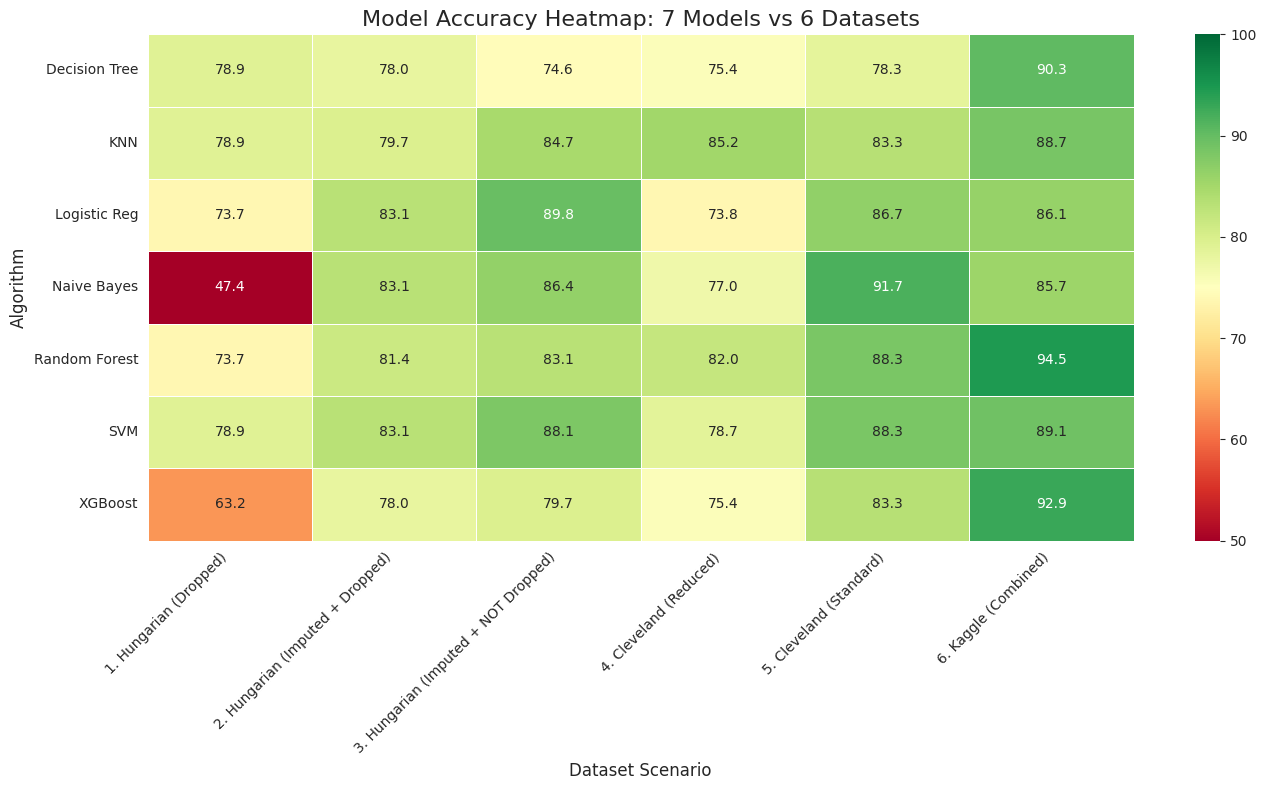

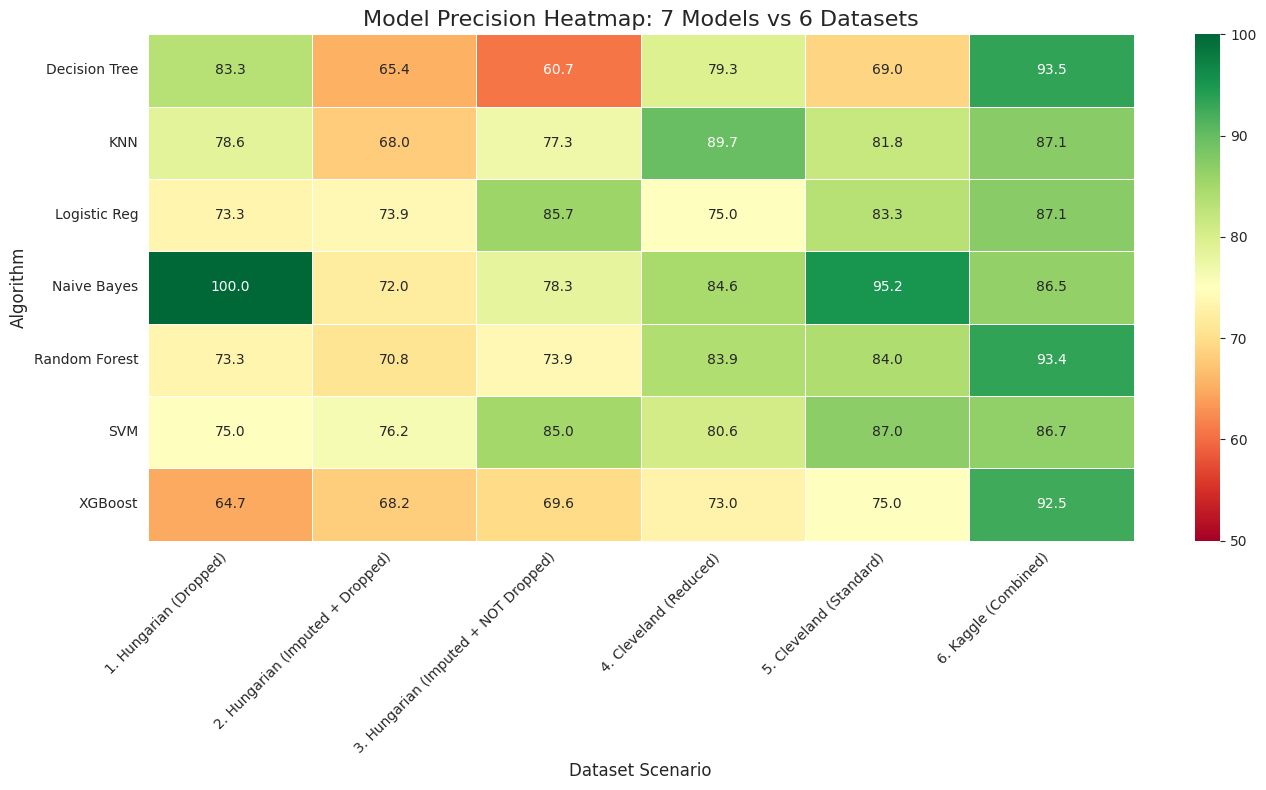

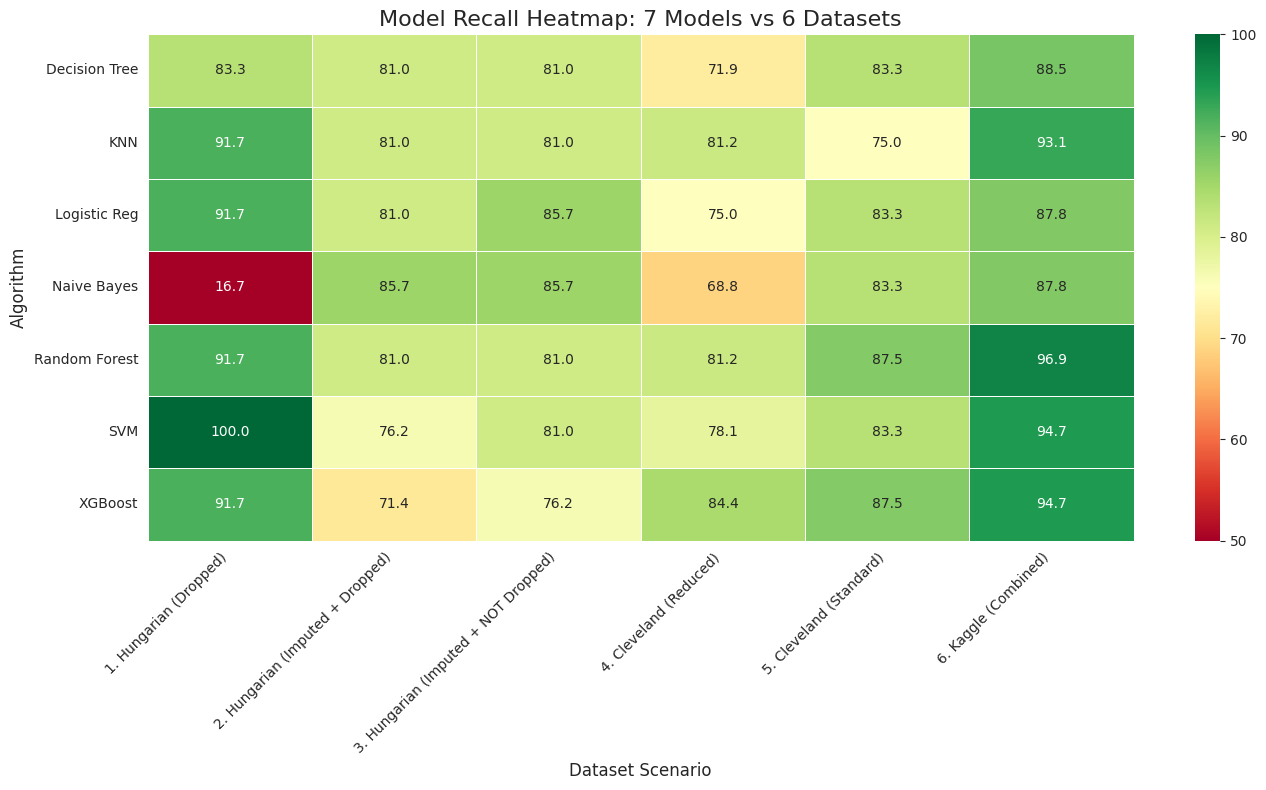

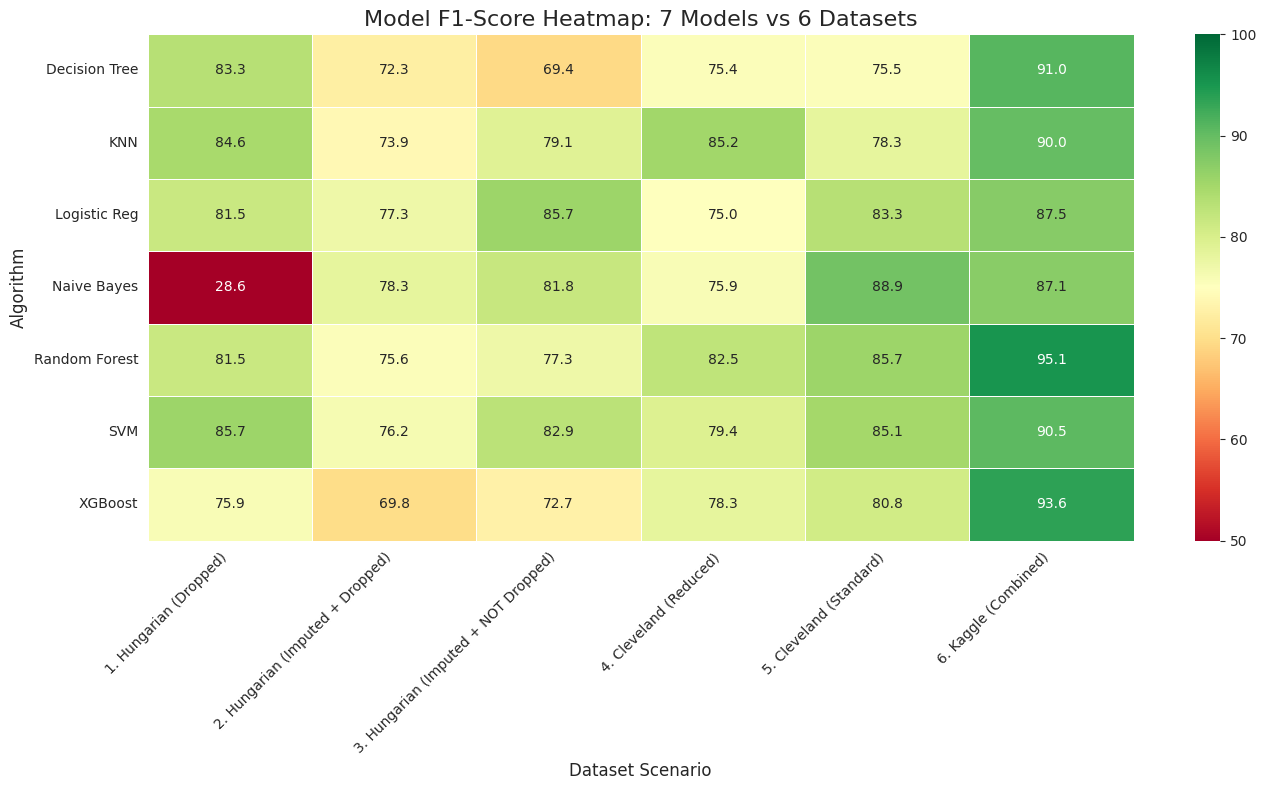

In [46]:
# ==========================================
# 5. GENERATE HEATMAPS
# ==========================================

all_results = []

for dataset_name, df in final_tables.items():
    df_temp = df.copy()
    df_temp['Dataset'] = dataset_name
    all_results.append(df_temp)

df_all = pd.concat(all_results)

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric in metrics_to_plot:
    pivot_table = df_all.pivot(index="Model", columns="Dataset", values=metric)

    plt.figure(figsize=(14, 8)) # Slightly wider for better readability

    sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="RdYlGn", linewidths=.5, vmin=50, vmax=100)

    plt.title(f"Model {metric} Heatmap: 7 Models vs 6 Datasets", fontsize=16)
    plt.ylabel("Algorithm", fontsize=12)
    plt.xlabel("Dataset Scenario", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
